In [3]:
################################################################################################################################################################################
library(Seurat)
library(SeuratObject)
library(ggplot2)
library(cowplot)
library(dplyr)

library(gridExtra)
#library(hash)
library(ggsci)
#library(presto)

library(CellChat)
#library(tidyverse)
library(NMF)
library(ggalluvial)
library(patchwork)
library(svglite)
library(Matrix)
library(rjson)
library(RColorBrewer)

library(ggrastr)#格栅化文件大小


suppressMessages(library(Seurat))
suppressMessages(library(SeuratObject))

suppressMessages(library(ggplot2))
suppressMessages(library(patchwork))
suppressMessages(library(dplyr))
suppressMessages(library(data.table))
suppressMessages(library(Matrix))
suppressMessages(library(rjson))
suppressMessages(library(RColorBrewer))
library(SingleCellExperiment)
 

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘packa

In [4]:
gem_2_rds <- function(gem, prefix, binsize){
    #' group counts into bins
    data=fread(file=gem)
    colnames(data)=c("geneID","x","y","MIDCounts")
    data$x <- trunc(data$x / binsize) * binsize
    data$y <- trunc(data$y / binsize) * binsize
    #trunc取整函数，只取整数部分
    #将横纵坐标根据binsize取整，比如，如果binszie=10,x=2401,y=4522,
    #那么处理后，x=2400,y=4520
    
    if ('MIDCounts' %in% colnames(data)) {
#       <- aggregate(data$MIDCounts,by=list(data$geneID,data$x,data$y),FUN=sum)
      # aa %in% bb，判断aa是否存在于bb中
      data <- data[, .(counts=sum(MIDCounts)), by = .(geneID, x, y)]
    } else {
      data <- data[, .(counts=sum(UMICount)), by = .(geneID, x, y)]
    }
    
    #' create sparse matrix from stereo
    data$cell <- paste0(prefix, ':', data$x, '_', data$y)
    data$geneIdx <- match(data$geneID, unique(data$geneID))
    data$cellIdx <- match(data$cell, unique(data$cell))
    #match(aa,bb)返回bb在aa中的位置
    
    # if (! is.null(opts$binsize)){
    #   #is.null(aa) 判断aa是否为空，如果空，返回Ture；
    #   #! is.null(aa)，相反地，判断aa是否非空，如果非空，返回True；
    #   write.table(data, file = paste0(opts$outdir, '/', opts$sample, '_bin', opts$binsize, '.tsv'), 
    #               quote = FALSE, sep = '\t', row.names = FALSE)
    # }
    #write.table(aa,file=xx,sep =" ",quote=TRUE,row.names =TRUE, col.names =TRUE)
    #把内容aa输出到文件xx中
    
    mat <- sparseMatrix(i = data$geneIdx, j = data$cellIdx, x = data$counts, 
                        dimnames = list(unique(data$geneID), unique(data$cell)))
    #sparseMatrix稀疏矩阵函数
    
    cell_coords <- unique(data[, c('cell', 'x', 'y')])
    #unique去除重复函数，删除cell,x和y都一样的行
    
    rownames(cell_coords) <- cell_coords$cell
    
    #cell_coords$cell <- NULL
    
    seurat_spatialObj <- CreateSeuratObject(counts = mat, project = 'Stereo', assay = 'Spatial', 
                                            names.delim = ':', meta.data = cell_coords)
    
    
    #' create pseudo image
    cell_coords$x <- cell_coords$x - min(cell_coords$x) + 1
    cell_coords$y <- cell_coords$y - min(cell_coords$y) + 1
    
    tissue_lowres_image <- matrix(1, max(cell_coords$y), max(cell_coords$x))
    #matrix(aa,x,y)以aa为输入向量，创建一个x行y列的矩阵
    #构造一个seruat image
    
    tissue_positions_list <- data.frame(row.names = cell_coords$cell,
                                        tissue = 1,
                                        row = cell_coords$y, col = cell_coords$x,
                                        imagerow = cell_coords$y, imagecol = cell_coords$x)
    
    
    scalefactors_json <- toJSON(list(fiducial_diameter_fullres = binsize,
                                     tissue_hires_scalef = 1,
                                     tissue_lowres_scalef = 1))
    #toJSON: 把json格式 转换成 list格式
    
    
    #' function to create image object
    generate_spatialObj <- function(image, scale.factors, tissue.positions, filter.matrix = TRUE){
      if (filter.matrix) {
        tissue.positions <- tissue.positions[which(tissue.positions$tissue == 1), , drop = FALSE]
      }
      
      unnormalized.radius <- scale.factors$fiducial_diameter_fullres * scale.factors$tissue_lowres_scalef
      
      spot.radius <- unnormalized.radius / max(dim(x = image))
      
      return(new(Class = 'VisiumV1', 
                 image = image, 
                 scale.factors = scalefactors(spot = scale.factors$tissue_hires_scalef, 
                                              fiducial = scale.factors$fiducial_diameter_fullres, 
                                              hires = scale.factors$tissue_hires_scalef, 
                                              lowres = scale.factors$tissue_lowres_scalef), 
                 coordinates = tissue.positions, 
                 spot.radius = spot.radius))
    }
    
    spatialObj <- generate_spatialObj(image = tissue_lowres_image, 
                                      scale.factors = fromJSON(scalefactors_json), 
                                      tissue.positions = tissue_positions_list)
    #可以理解为构建一个spatial背景
    
    #' import image into seurat object
    spatialObj <- spatialObj[Cells(x = seurat_spatialObj)]
    DefaultAssay(spatialObj) <- 'Spatial'
    
    seurat_spatialObj[['slice1']] <- spatialObj
    rm("spatialObj")
    rm("data")
    rm("mat")
    
    return(seurat_spatialObj)
    }  

In [5]:
# （3）绘制每个bin下基因表达个数热图或转录本热图, 需要调用自定义的色板子函数
heatmap_Palette <- colorRampPalette(rev(brewer.pal(11, 'Spectral')))
iPlot <- function(object, features, pt.size = 0.1, cluster_Palette = ColorPalette(50)){
    x_max=max(object@meta.data$x)
    y_min=min(object@meta.data$y)
    plot <- ggplot(object@meta.data, aes_string(x = 'x', y = 'y', color = features)) +
            geom_point_rast(shape = 19, size = pt.size) +
            #geom_point_rast(size=0.1, raster.dpi = getOption("ggrastr.default.dpi", 300))
            theme(axis.text = element_blank(), axis.ticks = element_blank(), panel.grid = element_blank(),
                  axis.title = element_blank(), axis.line = element_blank(), legend.position = 'right') +
            coord_fixed()
    
   #if (features %in% c('nCount_Spatial', 'nFeature_Spatial','Plasma1','C11')){
    if (features %in% names(object@meta.data)){
        plot <- plot + scale_color_gradientn(colours = heatmap_Palette(100))+
        annotate("segment", x = x_max-600, xend = x_max-1000, y = y_min-500, yend =y_min-500,size = 1,arrow = arrow(ends = "both", angle = 90, length = unit(.1,"cm")))+
        annotate("text", x = x_max-200, y = y_min-300, label = "200 um",color="black",size =4 )
    }else if(features %in% c('celltype', 'seurat_clusters')){
        plot <- plot + scale_color_manual(values = cluster_Palette) +
                guides(colour = guide_legend(override.aes = list(size=3), nrow = 4))+
        annotate("segment", x = x_max-600, xend = x_max-1000, y = y_min-500, yend =y_min-500,size = 1,arrow = arrow(ends = "both", angle = 90, length = unit(.1,"cm")))+
        annotate("text", x = x_max-200, y = y_min-300, label = "200 um",color="black",size =4)
    }
    plot <- plot + theme_void()
    
    return(plot)
}

In [6]:
# （6）贝叶斯聚类和贝叶斯绘图

###https://edward130603.github.io/BayesSpace/articles/BayesSpace.html

###https://edward130603.github.io/BayesSpace/articles/BayesSpace.html

BayesDat<-function(rds,output_dir,sampleID){
 
    library(BayesSpace)
    library(SingleCellExperiment)
    library(ggplot2)
    library(Seurat)
    library(stringr)


    df=readRDS(rds)

    counts = as(df@assays$Spatial@counts, "dgCMatrix")
    bins_infor=colnames(counts)
    x=as.numeric(str_split_fixed(bins_infor, "[:_]", 4)[,2]) #SS200000756BR_E3:13750_6550,格式必须一致
    y=as.numeric(str_split_fixed(bins_infor, "[:_]", 4)[,3]) #SS200000756BR_E3:13750_6550,格式必须一致
    colData=data.frame(bins_infor,x,y)
    names(colData) = c( "spot", "row", "col" )
    rownames(colData) = colData$spot
    genes = rownames(counts)
    rowData = data.frame(genes)

    bayesrdsfile <- SingleCellExperiment(assays=list(counts=counts),rowData=rowData,colData=colData)

    set.seed(102)
    bayesrdsfile <- spatialPreprocess(bayesrdsfile, platform="ST",n.PCs=30, n.HVGs=3000, log.normalize=TRUE)

    bayesrdsfile = qTune(bayesrdsfile, qs=seq(2, 3), platform="ST", d=7)
    myplot=qPlot(bayesrdsfile)
    ggsave(paste(output_dir,"/",sampleID,".bayescluster.qplot.pdf",sep=""),plot=myplot,width=8,height=8)
    return(bayesrdsfile)
}

BayesCluster<-function(rds,bayesrdsfile,output_dir,sampleID,cluster_count=3){
    
    df=readRDS(rds)
    set.seed(149)
    bayesrdsfile <- spatialCluster(bayesrdsfile, q=cluster_count, platform="ST", d=7,init.method="mclust", model="t", gamma=2,nrep=1000, burn.in=100,save.chain=TRUE)
    df@meta.data$spatial.cluster=colData(bayesrdsfile)$spatial.cluster
    Idents(df)=df@meta.data$spatial.cluster
    #markers <- FindAllMarkers(df, only.pos =FALSE, min.pct = 0.05,logfc.threshold = 0)
    markers <- FindAllMarkers(df, only.pos =FALSE, min.pct = 0.1)
    write.table(markers,file=paste(output_dir,"/",sampleID,".bayescluster.diff_markers.xls",sep=""),sep="\t",quote=F,row.names=F)
    write.table(colData(bayesrdsfile),file=paste(output_dir,"/",sampleID,".bayescluster.cluster_infor.xls",sep=""),sep="\t",quote=F,row.names=F)
    return(df)
}

BayesPlot=function(cluster_info, color, cluster="spatial.cluster",output_dir,sampleID){
    library(ggplot2)
    #color:几簇就给几个颜色
    ########## 00.读取聚类结果文件 ##########
    cluster_info <- read.table(cluster_info, header = TRUE, row.names = 1)
    cluster_info$spatial.cluster <- as.character(cluster_info$spatial.cluster)
    cluster_info$cluster.init <- as.character(cluster_info$cluster.init)
    ########## 01.画图 ##########
    p <- ggplot(data = cluster_info)+
        geom_point(aes_string(x="row", y="col", color = cluster), size = 3) +
        scale_colour_manual(name="",values = color)+
        theme_classic() +
        theme(panel.grid.major=element_blank(),panel.grid.minor=element_blank(), 
        plot.title = element_text(hjust = 0.5, size = 20),
        axis.text = element_blank(),
        axis.ticks = element_blank(),
        legend.title = element_text(face = "italic",family = "Times",colour = "red",size = 18),
        legend.text = element_text(colour = "blue",face = "italic",size = 18),
        axis.line = element_blank()) +
        guides(colour = guide_legend(override.aes=list(size=5)))+  #改变图例名称、大小guides, https://www.jianshu.com/p/07f7931a00db
        xlab("") + ylab("")+coord_fixed()
    p
    ggsave(p, filename=paste(output_dir,"/",sampleID,".bayescluster.spacialplot.pdf",sep=""), width=8, height=8)
}


In [26]:
gen_exp=function(rds=spf_local_rds,gene="Cr2"){
    gen=FetchData(rds,vars=gene)
    nam=rownames(gen)
    gen=apply(gen,1,sum)
    
    x=as.numeric(str_split_fixed(nam, "[:_]", 4)[,2]) #SS200000756BR_E3:13750_6550,格式必须一致
    y=as.numeric(str_split_fixed(nam, "[:_]", 4)[,3]) #SS200000756BR_E3:13750_6550,格式必须一致
    new=data.frame(x,y,gen)
    colnames(new)=c("x","y","hotspot")
    pos=which(new$hotspot==0)
    new=new[-pos,]
    
    new$hotspot=1
   
    return(new)
}
gen_exp_filter=function(rds=spf_local_rds,gene=c("Acta2","Myl9")){
    gen=FetchData(rds,vars=gene)
    nam=rownames(gen)
    gen=apply(gen,1,sum)
   
    x=as.numeric(str_split_fixed(nam, "[:_]", 4)[,2]) #SS200000756BR_E3:13750_6550,格式必须一致
    y=as.numeric(str_split_fixed(nam, "[:_]", 4)[,3]) #SS200000756BR_E3:13750_6550,格式必须一致
    new=data.frame(x,y,gen)
    colnames(new)=c("x","y","hotspot")
    pos=which(new$hotspot==0)
    new=new[-pos,]
    pp=which(new$hotspot>1)
    new$hotspot=0
    new[pp,3]=1
    pp=which(new$hotspot==0)
    new=new[-pp,]
    return(new)
}

In [43]:
plot_region <- function(df, df2, symb="Cr2", point_size) {
  x_med = median(df$x)
  ymin = min(df$y)
  x1 = x_med - 500      # bin50 25um, 200/50 表示4个spot, 4*25=100um,  1000/50 * 25 = 500um
  x2 = x_med + 500
  y1 = ymin - 200
  R<-ggplot() +  
    geom_contour_filled(df,mapping=aes(x=x, y=y, z=as.numeric(Cell)),breaks=0:5) + 
    theme(axis.text = element_blank(), axis.ticks = element_blank(), panel.grid = element_blank(),                                                                                                                                     
          axis.title = element_blank(), axis.line = element_blank(), legend.position = 'right') +                                                                                                                                      
    coord_fixed()  + 
    #scale_fill_manual(labels = c("1","2","3","4","5","6"), values = c("#3d0b4f","#423176","#3e5386","#3f718b","#468e8b","#78c36e")) +
    scale_fill_manual(labels = c("1","2","3","4"), values = c("gray10","gray40","gray70","gray90")) +
    
    guides(fill=guide_legend(override.aes = list(size=5), nrow = 4, title = 'Layers'))  + 
    geom_point(df2, mapping=aes(x = x, y = y, color="hotsopt"), shape = 19, size = point_size,stroke=NA,col='red') +
    labs(caption=symb)+
    #scale_color_manual(labels=c(symb), values = c("#d7191c")) + 
    guides(colour = guide_legend(override.aes = list(size=3), nrow = 5, title = ''))  + 
    annotate("segment", x = x1, xend = x2, y = y1, yend =y1,size = 1) +
    annotate("text", x = x1+500, y = y1-200, label = "500 um",color="black",size = 3, fontface="bold" ) + 
    theme_void() 
  R
}

In [7]:
gf_three_local="/data/work/4.st_data/Spleen_GF_local.gem"
spf_local="/data/work/4.st_data/Spleen_SPF_local.gem"

In [11]:
gf_three_local_rds=gem_2_rds(gf_three_local,prefix="GF" , binsize=50)
spf_local_rds=gem_2_rds(spf_local,prefix="SPF" , binsize=50)
saveRDS(gf_three_local_rds,"/data/work/4.st_data/final_GF_local.rds")
saveRDS(spf_local_rds,"/data/work/4.st_data/final_SPF_local.rds")
f1=iPlot(spf_local_rds, features='nCount_Spatial', pt.size = 0.1, cluster_Palette = ColorPalette(50))
f2=iPlot(spf_local_rds, features='nFeature_Spatial', pt.size = 0.1, cluster_Palette = ColorPalette(50))
f5=iPlot(gf_three_local_rds, features='nCount_Spatial', pt.size = 0.1, cluster_Palette = ColorPalette(50))
f6=iPlot(gf_three_local_rds, features='nFeature_Spatial', pt.size = 0.1, cluster_Palette = ColorPalette(50))
options(repr.plot.width = 16,repr.plot.height =8)

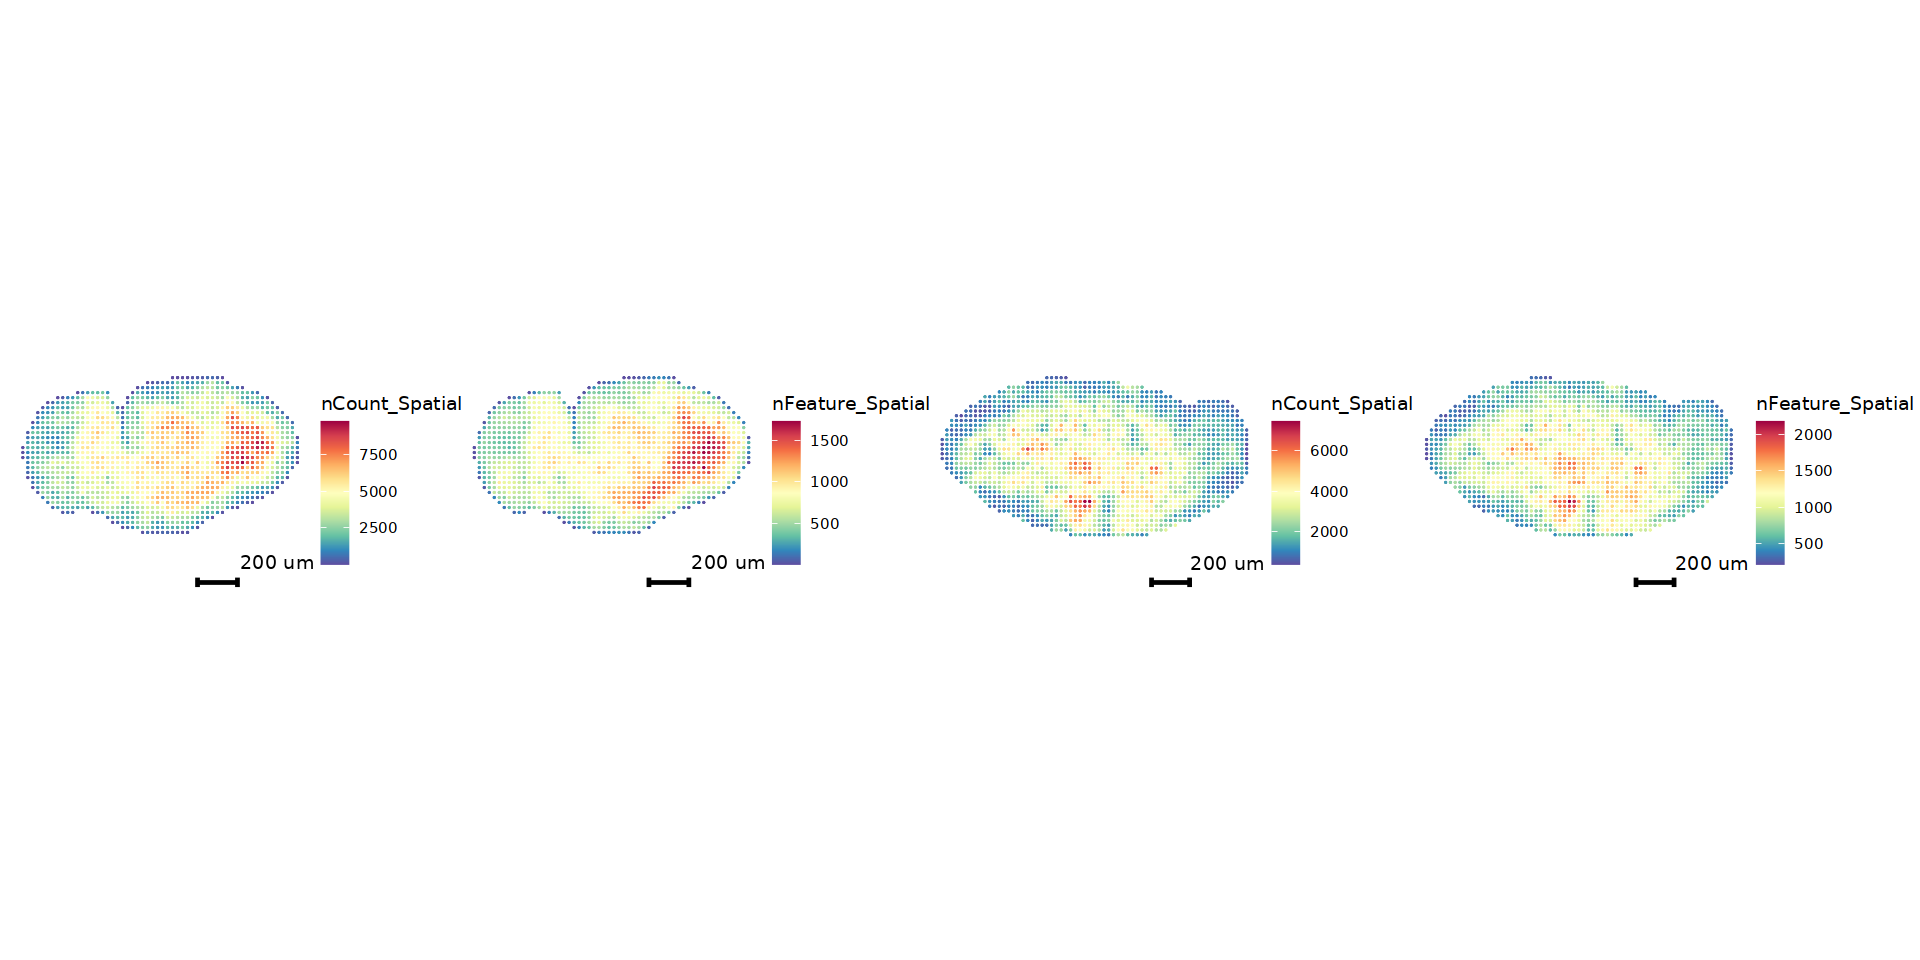

In [9]:
f5+f6+f1+f2+plot_layout(ncol = 4)

In [18]:
library(SingleCellExperiment)

rds1="/data/work/4.st_data/final_GF_local.rds"
rds2="/data/work/4.st_data/final_SPF_local.rds"

gf_local_bayesrdsfile=BayesDat(rds=rds1,output_dir="/data/work/4.st_data/bayes",sampleID="GF")
spf_local_bayesrdsfile=BayesDat(rds=rds2,output_dir="/data/work/4.st_data/bayes",sampleID="SPF")
t1=BayesCluster(rds=rds1,gf_local_bayesrdsfile,output_dir="/data/work/4.st_data/bayes",sampleID="GF",cluster_count=4)
t2=BayesCluster(rds=rds2,spf_local_bayesrdsfile,output_dir="/data/work/4.st_data/bayes",sampleID="SPF",cluster_count=4)

Neighbors were identified for 0 out of 1340 spots.

Fitting model...

Fitting model...

Neighbors were identified for 0 out of 1701 spots.

Fitting model...

Fitting model...

Neighbors were identified for 0 out of 1340 spots.

Fitting model...

You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.

You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
If you want to read subsets of the dataset, you should testsmaller chunk sizes to improve read times.

Calculating labels using iterations 100 through 1000.

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Neighbors were identified for 0 out of 1701 spots.

Fitting model...

You created a large dataset with compression and chunking.
The chunk size is equal to the dataset dimensions.
I

In [19]:
cluster_info="/data/work/4.st_data/bayes/GF.bayescluster.cluster_infor.xls"
output_dir="/data/work/4.st_data/bayes"
color=c("gray10","gray40","gray60","gray90")
BayesPlot(cluster_info, color, cluster="spatial.cluster",output_dir,sampleID="GF")

cluster_info="/data/work/4.st_data/bayes/GF.bayescluster.cluster_infor.xls"
output_dir="/data/work/4.st_data/bayes"
color=c("gray10","gray40","gray60","gray90")
BayesPlot(cluster_info, color, cluster="spatial.cluster",output_dir,sampleID="SPF")


In [22]:
saveRDS(t1,file="/data/work/4.st_data/bayes/final_GF_local_add_cluster.rds")
saveRDS(t2,file="/data/work/4.st_data/bayes/final_GF_local_add_cluster.rds")

In [27]:
SPF_layer=read.table("/data/work/4.st_data/bayes/SPF.bayescluster.cluster_infor.xls",header=T)
GF_layer=read.table("/data/work/4.st_data/bayes/GF.bayescluster.cluster_infor.xls",header=T)

In [30]:
table(GF_layer$spatial.cluster)


  1   2   3   4 
418 576 318  28 

In [36]:
head(GF_layer)

,spot,row,col,sizeFactor,cluster.init,spatial.cluster
,<chr>,<int>,<int>,<dbl>,<int>,<int>
1,GF:15300_11500,15300,11500,1.4920493,2,1
2,GF:15200_11350,15200,11350,1.6443311,1,1
3,GF:14250_11150,14250,11150,0.8383325,2,2
4,GF:14900_11600,14900,11600,1.4693634,2,1
5,GF:15150_11650,15150,11650,1.6065214,1,1
6,GF:15800_11900,15800,11900,1.3332485,2,2


In [31]:
p1=which(GF_layer$spatial.cluster==1)
p2=which(GF_layer$spatial.cluster==2)
p3=which(GF_layer$spatial.cluster==3)
p4=which(GF_layer$spatial.cluster==4)

In [38]:
head(GF_layer)

,spot,row,col,sizeFactor,cluster.init,spatial.cluster
,<chr>,<int>,<int>,<dbl>,<int>,<int>
1,GF:15300_11500,15300,11500,1.4920493,2,1
2,GF:15200_11350,15200,11350,1.6443311,1,1
3,GF:14250_11150,14250,11150,0.8383325,2,2
4,GF:14900_11600,14900,11600,1.4693634,2,1
5,GF:15150_11650,15150,11650,1.6065214,1,1
6,GF:15800_11900,15800,11900,1.3332485,2,2


In [41]:
gf_three_local_rds

An object of class Seurat 
24416 features across 1340 samples within 1 assay 
Active assay: Spatial (24416 features, 0 variable features)
 1 image present: slice1

In [50]:
df=GF_layer[,c(2,3,6)]
names(df)=c("x","y","Cell")
rownames(df)=paste("GF:",df[,1],"_",df[,2],sep="")
df_Cr2=gen_exp(gf_three_local_rds,gene="Cr2")
df_Ighd=gen_exp(gf_three_local_rds,gene="Ighd")
df_Ctla4=gen_exp(gf_three_local_rds,gene="Ctla4")
df_Marco=gen_exp(gf_three_local_rds,gene="Marco")

f1=plot_region(df, df_Cr2, symb="MZ cell(Cr2)", point_size=1.8) 
f2=plot_region(df, df_Ighd, symb="FC cell(Ighd)", point_size=1.8) 
f3=plot_region(df, df_Ctla4, symb="T cell(Ctla4)", point_size=1.8) 
f4=plot_region(df, df_Marco, symb="Macrophage (Marco)", point_size=1.8) 

df_Cr2_fil=gen_exp_filter(gf_three_local_rds,gene="Cr2")
df_Ighd_fil=gen_exp_filter(gf_three_local_rds,gene="Ighd")
df_Ctla4_fil=gen_exp_filter(gf_three_local_rds,gene="Ctla4")
df_Marco_fil=gen_exp_filter(gf_three_local_rds,gene="Marco")

f1=plot_region(df, df_Cr2_fil, symb="MZ cell(Cr2)", point_size=1.8) 
f2=plot_region(df, df_Ighd_fil, symb="FC cell(Ighd)", point_size=1.8) 
f3=plot_region(df, df_Ctla4_fil, symb="T cell(Ctla4)", point_size=1.8) 
f4=plot_region(df, df_Marco_fil, symb="Macrophage (Marco)", point_size=1.8) 



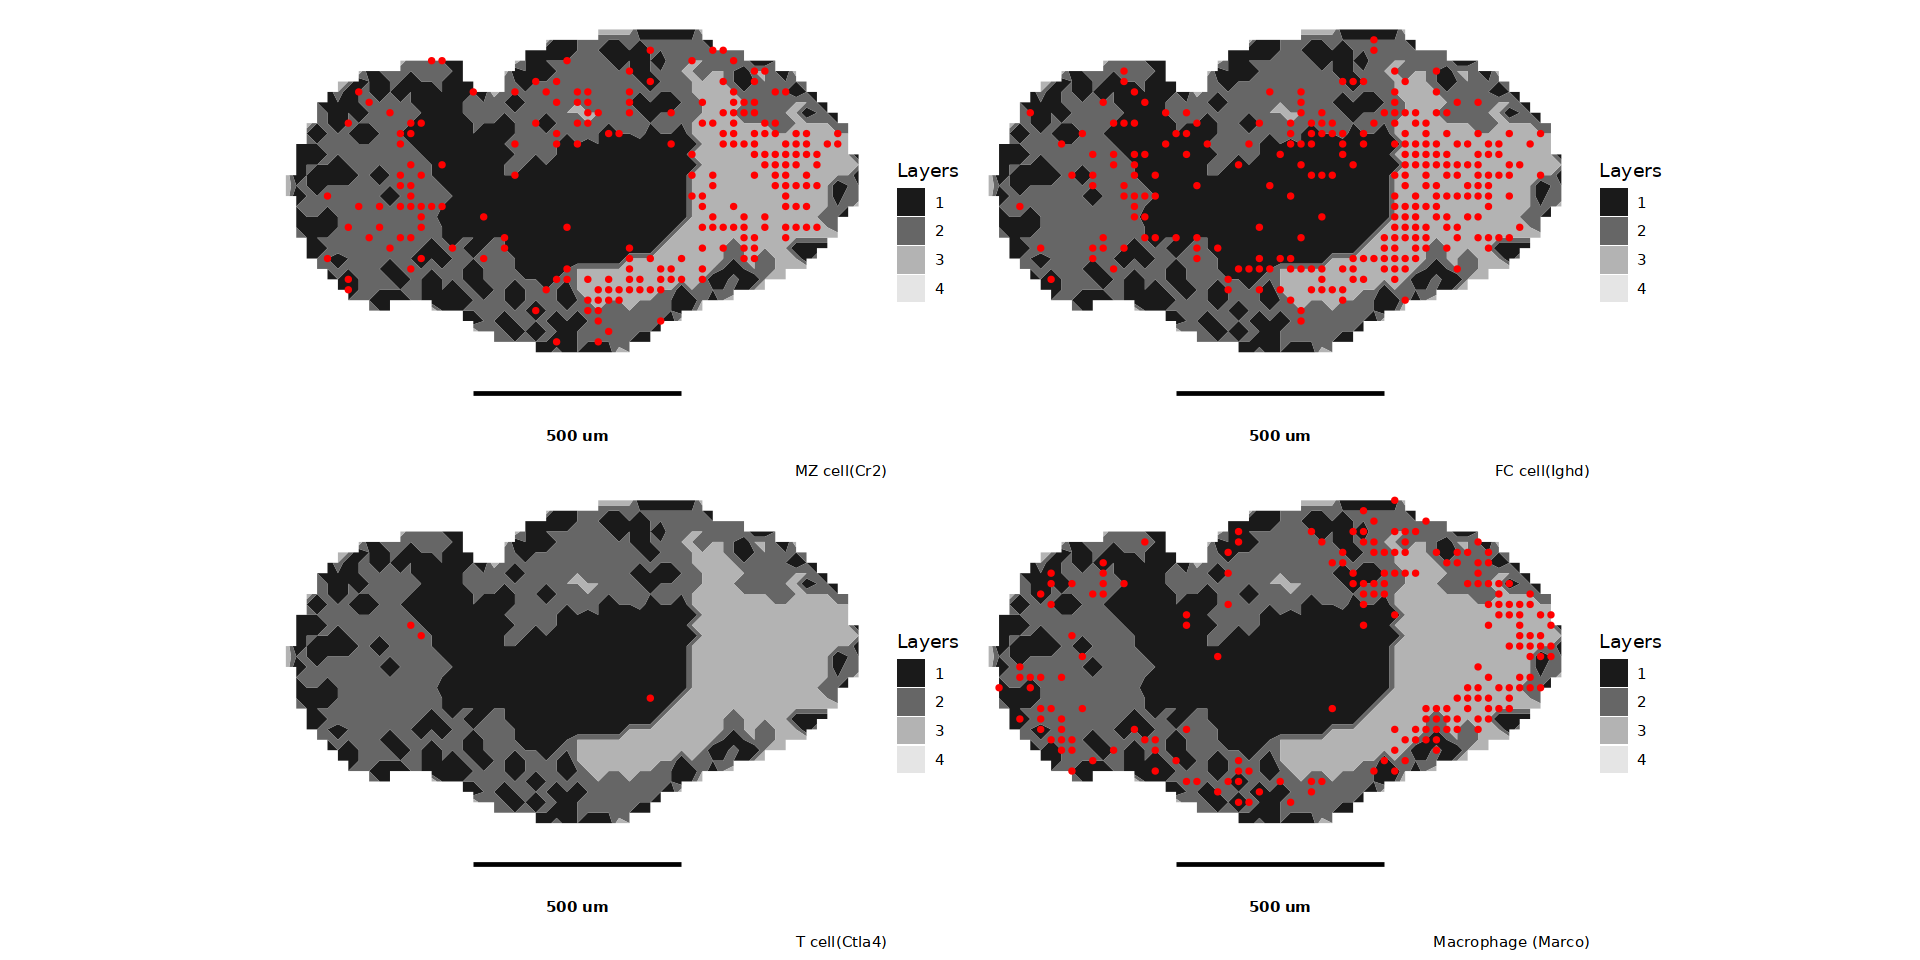

In [52]:
f1+f2+f3+f4

In [53]:
df=SPF_layer[,c(2,3,6)]
names(df)=c("x","y","Cell")
rownames(df)=paste("SPF:",df[,1],"_",df[,2],sep="")
df_Cr2=gen_exp(spf_local_rds,gene="Cr2")
df_Ighd=gen_exp(spf_local_rds,gene="Ighd")
df_Ctla4=gen_exp(spf_local_rds,gene="Ctla4")
df_Marco=gen_exp(spf_local_rds,gene="Marco")

f1=plot_region(df, df_Cr2, symb="MZ cell(Cr2)", point_size=1.8) 
f2=plot_region(df, df_Ighd, symb="FC cell(Ighd)", point_size=1.8) 
f3=plot_region(df, df_Ctla4, symb="T cell(Ctla4)", point_size=1.8) 
f4=plot_region(df, df_Marco, symb="Macrophage (Marco)", point_size=1.8) 

df_Cr2_fil=gen_exp_filter(spf_local_rds,gene="Cr2")
df_Ighd_fil=gen_exp_filter(spf_local_rds,gene="Ighd")
df_Ctla4_fil=gen_exp_filter(spf_local_rds,gene="Ctla4")
df_Marco_fil=gen_exp_filter(spf_local_rds,gene="Marco")

f1=plot_region(df, df_Cr2_fil, symb="MZ cell(Cr2)", point_size=1.8) 
f2=plot_region(df, df_Ighd_fil, symb="FC cell(Ighd)", point_size=1.8) 
f3=plot_region(df, df_Ctla4_fil, symb="T cell(Ctla4)", point_size=1.8) 
f4=plot_region(df, df_Marco_fil, symb="Macrophage (Marco)", point_size=1.8) 



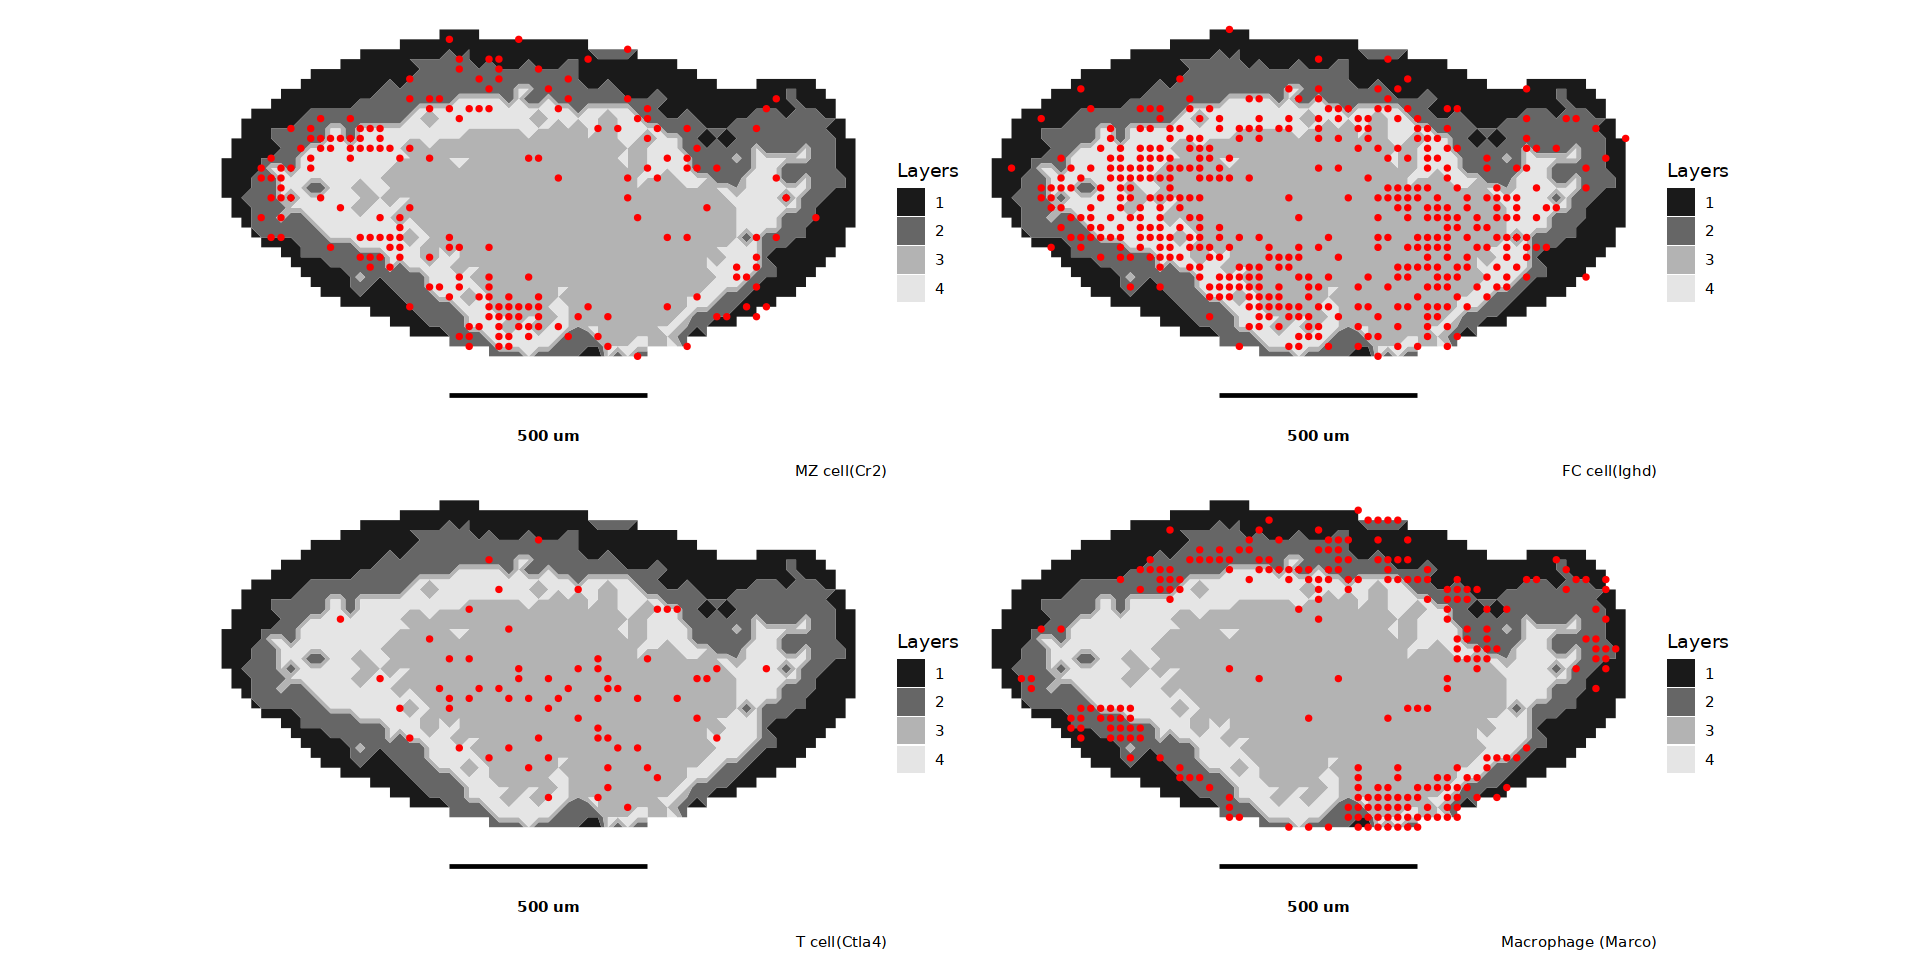

In [54]:
f1+f2+f3+f4

In [ ]:
########Antimicrobials.gene

f1=plot_region(df, df_Slpi, symb="Antimicrobials gene(Slpi)", point_size=1.8) 
f2=plot_region(df, df_Isg15, symb="Antimicrobials gene(Isg15)", point_size=1.8) 
f3=plot_region(df, df_Ccl5, symb="Antimicrobials gene(Ccl5)", point_size=1.8) 
f4=plot_region(df, df_Ccr7, symb="Antimicrobials gene(Ccr7)", point_size=1.8) 
f5=plot_region(df, df_Irf1, symb="Antimicrobials gene(Irf1)", point_size=1.5) 

options(repr.plot.width = 12,repr.plot.height =3)
pdf("/zfssz2/ST_TSCBI/P22Z10200N0433/USER/shenjuan/package/GF_SPF/st/spleen/local/GF/bin50/three/cluster5/GF_local_Antimicrobials.pdf",w=12,h=8)
grid.arrange(f1, f2, f3, f4,f5, ncol=5)